<a href="https://colab.research.google.com/github/maverick8675309/seaid-framework/blob/main/06_Random_Forest_Temporal_Early_Warning.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# Random Forest Early-Warning Model: Day 30

This notebook develops and evaluates a Random Forest classifier using the Day 30 early-warning dataset created for the SEAID Framework.

The model uses only information available on or before Day 30 of the course. Its performance will be compared with the Day 30 Logistic Regression and Decision Tree models to determine whether an ensemble learning approach improves early prediction of student outcomes.

## Notebook Objectives

1. Load and inspect the Day 30 modeling dataset.
2. Prepare the predictor variables and target variable.
3. Create training and testing datasets.
4. Train a Random Forest classifier.
5. Evaluate model performance using accuracy, precision, recall, F1 score, ROC-AUC, a classification report, a confusion matrix, and an ROC curve.
6. Examine feature importance.
7. Save the trained model and evaluation outputs.
8. Compare the Random Forest results with the Logistic Regression and Decision Tree models.

In [1]:
import warnings
warnings.filterwarnings("ignore")

from pathlib import Path

import joblib
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd

from sklearn.compose import ColumnTransformer
from sklearn.ensemble import RandomForestClassifier
from sklearn.impute import SimpleImputer
from sklearn.metrics import (
    accuracy_score,
    classification_report,
    confusion_matrix,
    ConfusionMatrixDisplay,
    f1_score,
    precision_score,
    recall_score,
    roc_auc_score,
    RocCurveDisplay
)
from sklearn.model_selection import train_test_split
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import OneHotEncoder

pd.set_option("display.max_columns", None)
pd.set_option("display.max_rows", 100)

RANDOM_STATE = 42

print("Libraries imported successfully.")

Libraries imported successfully.


In [2]:
from google.colab import drive

drive.mount("/content/drive")

Mounted at /content/drive


In [3]:
PROJECT_DIR = Path("/content/drive/MyDrive/SEAID_Framework")

DATA_DIR = PROJECT_DIR / "data" / "processed"
NOTEBOOK_DIR = PROJECT_DIR / "notebooks"
MODEL_DIR = PROJECT_DIR / "models"
OUTPUT_DIR = PROJECT_DIR / "outputs"
FIGURE_DIR = PROJECT_DIR / "figures"

DATA_PATH = DATA_DIR / "final_modeling_dataset_day30.csv"

MODEL_DIR.mkdir(parents=True, exist_ok=True)
OUTPUT_DIR.mkdir(parents=True, exist_ok=True)
FIGURE_DIR.mkdir(parents=True, exist_ok=True)

print("Project directory:", PROJECT_DIR)
print("Dataset path:", DATA_PATH)
print("Dataset exists:", DATA_PATH.exists())

Project directory: /content/drive/MyDrive/SEAID_Framework
Dataset path: /content/drive/MyDrive/SEAID_Framework/data/processed/final_modeling_dataset_day30.csv
Dataset exists: True


## Load the Day 30 Modeling Dataset

This section loads the processed Day 30 early-warning dataset and verifies its dimensions and structure.

In [4]:
modeling_data = pd.read_csv(DATA_PATH)

print("Dataset loaded successfully.")
print("Dataset shape:", modeling_data.shape)

display(modeling_data.head())

Dataset loaded successfully.
Dataset shape: (32593, 77)


,code_module,code_presentation,id_student,gender,num_of_prev_attempts,studied_credits,disability,final_result,target_success,total_clicks,average_clicks_per_record,median_clicks_per_record,maximum_clicks_in_record,vle_records,active_days,unique_vle_activities,first_activity_day,last_activity_day,clicks_per_active_day,activity_span_days,clicks_per_vle_activity,log_total_clicks,assessments_completed,average_score,median_score,minimum_score,maximum_score,score_std,average_weight,total_weight_completed,first_submission_day,last_submission_day,banked_assessments,assessment_span_days,score_range,weighted_average_score,score_improvement,assessment_intensity,log_assessments_completed,date_registration,registered_before_start,registered_after_start,days_registered_before_start,region_East Midlands Region,region_Ireland,region_London Region,region_North Region,region_North Western Region,region_Scotland,region_South East Region,region_South Region,region_South West Region,region_Wales,region_West Midlands Region,region_Yorkshire Region,highest_education_HE Qualification,highest_education_Lower Than A Level,highest_education_No Formal quals,highest_education_Post Graduate Qualification,imd_band_10-20,imd_band_20-30%,imd_band_30-40%,imd_band_40-50%,imd_band_50-60%,imd_band_60-70%,imd_band_70-80%,imd_band_80-90%,imd_band_90-100%,imd_band_Unknown,age_band_35-55,age_band_55<=,registration_timing_early,registration_timing_late,registration_timing_moderately_early,registration_timing_unknown,registration_timing_very_early,registration_timing_very_late
0,AAA,2013J,11391,0,0,240,0,Pass,1,424.0,6.424242,2.0,76.0,66.0,10.0,26.0,-5.0,30.0,42.400000,35.0,16.307692,6.052089,1.0,78.0,78.0,78.0,78.0,0.0,10.0,10.0,18.0,18.0,0.0,0.0,0.0,78.0,0.0,1.0,0.693147,-159.0,1,0,159.0,0,0,0,0,0,0,0,0,0,0,0,0,1,0,0,0,0,0,0,0,0,0,0,0,1,0,0,1,0,0,0,0,1,0
1,AAA,2013J,28400,1,0,60,0,Pass,1,618.0,3.862500,2.5,19.0,160.0,19.0,34.0,-10.0,28.0,32.526316,38.0,18.176471,6.428105,1.0,70.0,70.0,70.0,70.0,0.0,10.0,10.0,22.0,22.0,0.0,0.0,0.0,70.0,0.0,1.0,0.693147,-53.0,1,0,53.0,0,0,0,0,0,1,0,0,0,0,0,0,1,0,0,0,0,1,0,0,0,0,0,0,0,0,1,0,1,0,0,0,0,0
2,AAA,2013J,30268,1,0,60,1,Withdrawn,0,281.0,3.697368,2.0,23.0,76.0,12.0,22.0,-10.0,12.0,23.416667,22.0,12.772727,5.641907,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.000000,-92.0,1,0,92.0,0,0,0,0,1,0,0,0,0,0,0,0,0,0,0,0,0,0,1,0,0,0,0,0,0,0,1,0,0,0,0,0,1,0
3,AAA,2013J,31604,1,0,60,0,Pass,1,540.0,3.552632,2.0,22.0,152.0,24.0,32.0,-10.0,30.0,22.500000,40.0,16.875000,6.293419,1.0,72.0,72.0,72.0,72.0,0.0,10.0,10.0,17.0,17.0,0.0,0.0,0.0,72.0,0.0,1.0,0.693147,-52.0,1,0,52.0,0,0,0,0,0,0,1,0,0,0,0,0,0,0,0,0,0,0,0,0,1,0,0,0,0,0,1,0,1,0,0,0,0,0
4,AAA,2013J,32885,1,0,60,0,Pass,1,567.0,3.754967,2.0,22.0,151.0,24.0,34.0,-10.0,26.0,23.625000,36.0,16.676471,6.342121,1.0,69.0,69.0,69.0,69.0,0.0,10.0,10.0,26.0,26.0,0.0,0.0,0.0,69.0,0.0,1.0,0.693147,-176.0,1,0,176.0,0,0,0,0,0,0,0,0,0,0,1,0,0,1,0,0,0,0,0,0,1,0,0,0,0,0,0,0,0,0,0,0,1,0


## Prepare the Predictor Variables and Target

The binary target variable is `target_success`. The original `final_result` column is excluded because it directly contains the final course outcome and would create target leakage. The student identifier is also removed because it identifies records rather than representing a meaningful predictive feature.

In [5]:
TARGET = "target_success"

columns_to_drop = [
    TARGET,
    "final_result",
    "id_student"
]

X = modeling_data.drop(columns=columns_to_drop)
y = modeling_data[TARGET]

print("Predictor matrix shape:", X.shape)
print("Target vector shape:", y.shape)

print("\nTarget distribution:")
display(y.value_counts().sort_index())

print("\nTarget proportions:")
display(
    y.value_counts(normalize=True)
    .sort_index()
    .round(3)
)

Predictor matrix shape: (32593, 74)
Target vector shape: (32593,)

Target distribution:


,count
target_success,
0,17208
1,15385



Target proportions:


,proportion
target_success,
0,0.528
1,0.472


In [6]:
print("Target values:", sorted(y.unique()))
print("Missing target values:", y.isna().sum())
print("Duplicate predictor columns:", X.columns.duplicated().sum())

Target values: [np.int64(0), np.int64(1)]
Missing target values: 0
Duplicate predictor columns: 0


## Create Training and Testing Sets

The dataset is divided into training and testing subsets using an 80/20 split. Stratified sampling preserves the proportion of successful and unsuccessful students in both subsets.

In [7]:
X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.20,
    stratify=y,
    random_state=RANDOM_STATE
)

print("Training predictor shape:", X_train.shape)
print("Testing predictor shape:", X_test.shape)

print("\nTraining target proportions:")
display(y_train.value_counts(normalize=True).sort_index().round(3))

print("\nTesting target proportions:")
display(y_test.value_counts(normalize=True).sort_index().round(3))

Training predictor shape: (26074, 74)
Testing predictor shape: (6519, 74)

Training target proportions:


,proportion
target_success,
0,0.528
1,0.472



Testing target proportions:


,proportion
target_success,
0,0.528
1,0.472


## Create the Preprocessing Pipeline

Random Forest models do not require feature scaling. The preprocessing pipeline therefore handles missing values and encodes the remaining categorical variables before model training.

In [8]:
categorical_features = X_train.select_dtypes(
    include=["object", "category"]
).columns.tolist()

numeric_features = X_train.select_dtypes(
    include=["number", "bool"]
).columns.tolist()

print("Numeric features:", len(numeric_features))
print("Categorical features:", len(categorical_features))
print("Categorical feature names:", categorical_features)

Numeric features: 72
Categorical features: 2
Categorical feature names: ['code_module', 'code_presentation']


In [9]:
numeric_transformer = Pipeline(
    steps=[
        ("imputer", SimpleImputer(strategy="median"))
    ]
)

categorical_transformer = Pipeline(
    steps=[
        ("imputer", SimpleImputer(strategy="most_frequent")),
        ("encoder", OneHotEncoder(handle_unknown="ignore"))
    ]
)

preprocessor = ColumnTransformer(
    transformers=[
        ("num", numeric_transformer, numeric_features),
        ("cat", categorical_transformer, categorical_features)
    ],
    remainder="drop"
)

print("Preprocessing pipeline created successfully.")

Preprocessing pipeline created successfully.


## Train the Random Forest Classifier

This section combines the preprocessing steps with a Random Forest classifier. The model uses 500 decision trees and all available processor cores during training.

In [10]:
random_forest_pipeline = Pipeline(
    steps=[
        ("preprocessor", preprocessor),
        (
            "classifier",
            RandomForestClassifier(
                n_estimators=500,
                random_state=RANDOM_STATE,
                n_jobs=-1
            )
        )
    ]
)

random_forest_pipeline.fit(X_train, y_train)

print("Random Forest model trained successfully.")

Random Forest model trained successfully.


In [11]:
y_pred = random_forest_pipeline.predict(X_test)

y_prob = random_forest_pipeline.predict_proba(
    X_test
)[:, 1]

print("Predictions generated successfully.")

Predictions generated successfully.


## Evaluate Model Performance

This section evaluates the Random Forest classifier using accuracy, precision, recall, F1 score, and ROC-AUC. These metrics will be compared directly with the Logistic Regression and Decision Tree models.

In [12]:
accuracy = accuracy_score(y_test, y_pred)
precision = precision_score(y_test, y_pred)
recall = recall_score(y_test, y_pred)
f1 = f1_score(y_test, y_pred)
roc_auc = roc_auc_score(y_test, y_prob)

metrics_df = pd.DataFrame(
    {
        "Metric": [
            "Accuracy",
            "Precision",
            "Recall",
            "F1 Score",
            "ROC-AUC"
        ],
        "Value": [
            accuracy,
            precision,
            recall,
            f1,
            roc_auc
        ]
    }
)

display(metrics_df)

,Metric,Value
0,Accuracy,0.764841
1,Precision,0.723250
2,Recall,0.812805
3,F1 Score,0.765417
4,ROC-AUC,0.848734


In [13]:
print(f"Accuracy:  {accuracy:.4f}")
print(f"Precision: {precision:.4f}")
print(f"Recall:    {recall:.4f}")
print(f"F1 Score:  {f1:.4f}")
print(f"ROC-AUC:   {roc_auc:.4f}")

Accuracy:  0.7648
Precision: 0.7233
Recall:    0.8128
F1 Score:  0.7654
ROC-AUC:   0.8487


## Classification Report

The classification report provides precision, recall, F1 score, and support for each outcome class, offering a detailed assessment of the Random Forest classifier's predictive performance.

In [14]:
print(
    classification_report(
        y_test,
        y_pred,
        target_names=[
            "Unsuccessful",
            "Successful"
        ]
    )
)

              precision    recall  f1-score   support

Unsuccessful       0.81      0.72      0.76      3442
  Successful       0.72      0.81      0.77      3077

    accuracy                           0.76      6519
   macro avg       0.77      0.77      0.76      6519
weighted avg       0.77      0.76      0.76      6519



In [15]:
classification_report_df = pd.DataFrame(
    classification_report(
        y_test,
        y_pred,
        target_names=[
            "Unsuccessful",
            "Successful"
        ],
        output_dict=True
    )
).transpose()

display(classification_report_df)

,precision,recall,f1-score,support
Unsuccessful,0.811826,0.721964,0.764263,3442.000000
Successful,0.723250,0.812805,0.765417,3077.000000
accuracy,0.764841,0.764841,0.764841,0.764841
macro avg,0.767538,0.767384,0.764840,6519.000000
weighted avg,0.770018,0.764841,0.764808,6519.000000


## Confusion Matrix

The confusion matrix compares the Random Forest model's predicted outcomes with the observed student outcomes and summarizes correct and incorrect classifications.

In [16]:
confusion_matrix_values = confusion_matrix(
    y_test,
    y_pred
)

print(confusion_matrix_values)

[[2485  957]
 [ 576 2501]]


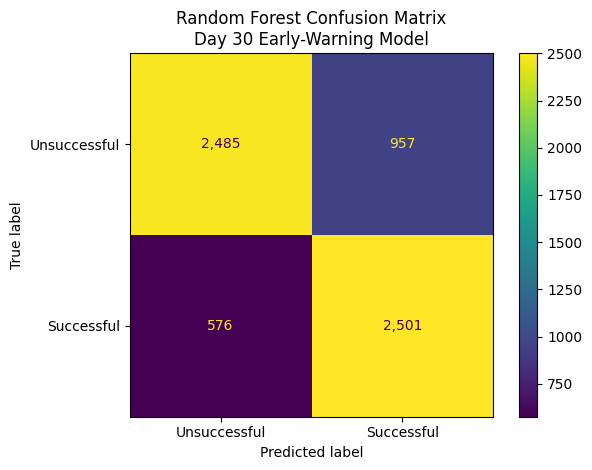

In [17]:
ConfusionMatrixDisplay(
    confusion_matrix=confusion_matrix_values,
    display_labels=[
        "Unsuccessful",
        "Successful"
    ]
).plot(values_format=",d")

plt.title(
    "Random Forest Confusion Matrix\nDay 30 Early-Warning Model"
)

plt.tight_layout()
plt.show()

## Receiver Operating Characteristic (ROC) Curve

The Receiver Operating Characteristic (ROC) curve illustrates the Random Forest classifier's ability to distinguish between successful and unsuccessful students across all possible classification thresholds.

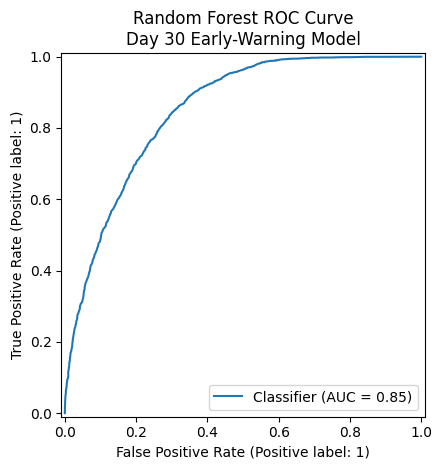

In [18]:
RocCurveDisplay.from_predictions(
    y_test,
    y_prob
)

plt.title(
    "Random Forest ROC Curve\nDay 30 Early-Warning Model"
)

plt.tight_layout()
plt.show()

## Feature Importance

Random Forest estimates feature importance by measuring the average reduction in impurity contributed by each predictor across all decision trees in the ensemble. Features with higher importance values have a greater influence on the model's predictions.

In [19]:
feature_names = (
    random_forest_pipeline.named_steps["preprocessor"]
    .get_feature_names_out()
)

feature_importance = (
    random_forest_pipeline.named_steps["classifier"]
    .feature_importances_
)

feature_importance_df = (
    pd.DataFrame(
        {
            "Feature": feature_names,
            "Importance": feature_importance
        }
    )
    .sort_values(
        by="Importance",
        ascending=False
    )
)

display(feature_importance_df.head(20))

,Feature,Importance
12,num__last_activity_day,0.052127
15,num__clicks_per_vle_activity,0.043337
19,num__median_score,0.040543
16,num__log_total_clicks,0.040433
8,num__vle_records,0.039908
9,num__active_days,0.039443
18,num__average_score,0.038976
4,num__total_clicks,0.038233
14,num__activity_span_days,0.036915
5,num__average_clicks_per_record,0.035603


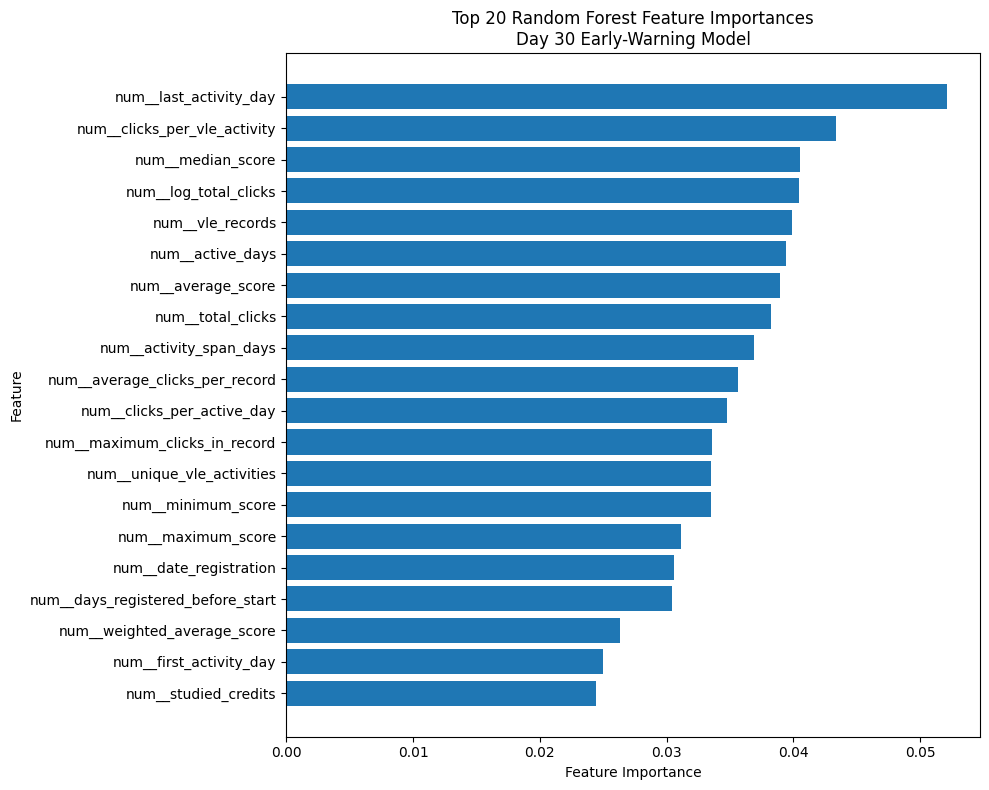

In [20]:
top_features = feature_importance_df.head(20)

plt.figure(figsize=(10,8))

plt.barh(
    top_features["Feature"][::-1],
    top_features["Importance"][::-1]
)

plt.xlabel("Feature Importance")
plt.ylabel("Feature")

plt.title(
    "Top 20 Random Forest Feature Importances\nDay 30 Early-Warning Model"
)

plt.tight_layout()
plt.show()

## Feature Importance Interpretation

The Random Forest model identified **last_activity_day** as the single most influential predictor of student success by Day 30. This finding suggests that continued engagement later into the first month of the course is strongly associated with successful course completion.

Unlike the single Decision Tree model, the Random Forest distributed importance across a broader set of variables. Multiple indicators of student engagement—including clicks per VLE activity, total clicks, active days, VLE records, activity span, and average clicks per record—ranked among the most influential predictors. This pattern indicates that sustained participation in the online learning environment provides valuable information for identifying students who may require early intervention.

Assessment performance also contributed substantially to prediction. Variables such as median score, average score, minimum score, maximum score, and weighted average score all appeared among the twenty most important predictors, demonstrating that early academic achievement complements behavioral engagement when forecasting final course outcomes.

Registration-related variables, including date of registration and the number of days registered before the course began, also contributed to prediction, although their influence was smaller than engagement and assessment measures.

Overall, the feature importance results demonstrate that the Random Forest classifier captures meaningful relationships across multiple dimensions of student behavior rather than relying heavily on a single predictor. This balanced use of information likely contributed to the model's superior predictive performance compared with both the Logistic Regression and Decision Tree models.

## Save the Trained Model

The trained Random Forest model is saved for future prediction and comparison with other machine learning models developed within the SEAID Framework.

In [21]:
MODEL_PATH = MODEL_DIR / "random_forest_early_warning_day30.joblib"

joblib.dump(
    random_forest_pipeline,
    MODEL_PATH
)

print("Model saved to:")
print(MODEL_PATH)

Model saved to:
/content/drive/MyDrive/SEAID_Framework/models/random_forest_early_warning_day30.joblib


## Save Evaluation Results

Save evaluation metrics, the classification report, and feature importance rankings for later comparison across models.

In [22]:
metrics_df.to_csv(
    OUTPUT_DIR / "random_forest_early_warning_metrics.csv",
    index=False
)

classification_report_df.to_csv(
    OUTPUT_DIR / "random_forest_classification_report.csv"
)

feature_importance_df.to_csv(
    OUTPUT_DIR / "random_forest_feature_importance.csv",
    index=False
)

print("Evaluation outputs saved.")

Evaluation outputs saved.


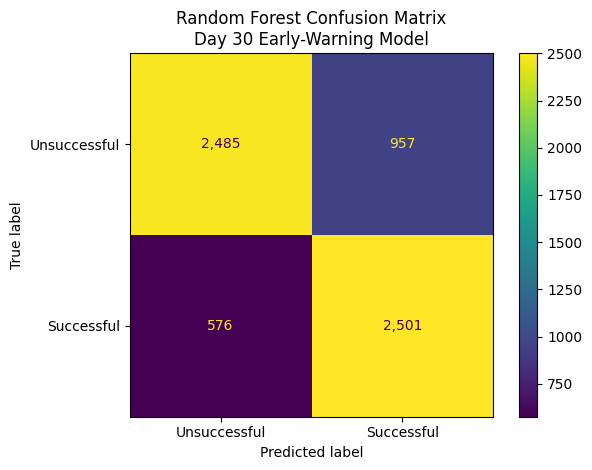

In [23]:
ConfusionMatrixDisplay(
    confusion_matrix=confusion_matrix_values,
    display_labels=[
        "Unsuccessful",
        "Successful"
    ]
).plot(values_format=",d")

plt.title(
    "Random Forest Confusion Matrix\nDay 30 Early-Warning Model"
)

plt.tight_layout()

plt.savefig(
    FIGURE_DIR / "random_forest_confusion_matrix.png",
    dpi=300,
    bbox_inches="tight"
)

plt.show()

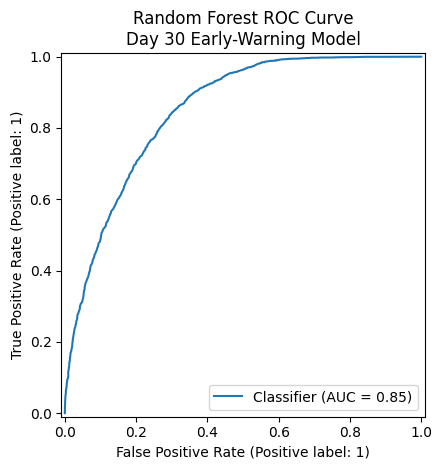

In [24]:
RocCurveDisplay.from_predictions(
    y_test,
    y_prob
)

plt.title(
    "Random Forest ROC Curve\nDay 30 Early-Warning Model"
)

plt.tight_layout()

plt.savefig(
    FIGURE_DIR / "random_forest_roc_curve.png",
    dpi=300,
    bbox_inches="tight"
)

plt.show()

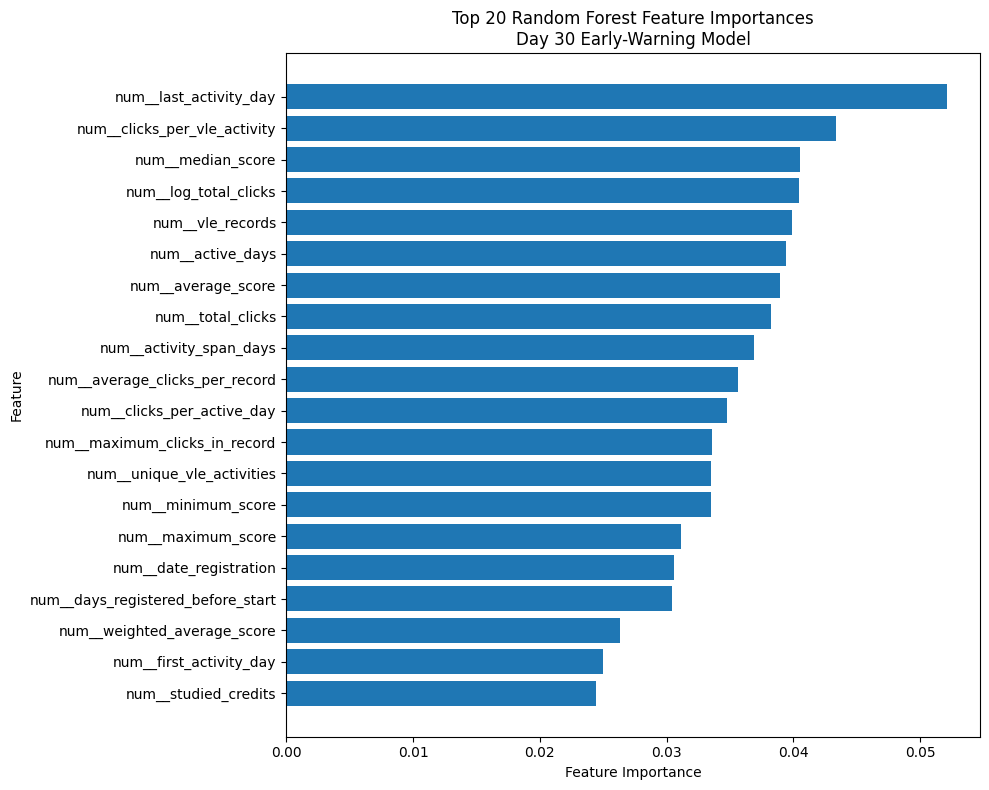

In [25]:
top_features = feature_importance_df.head(20)

plt.figure(figsize=(10,8))

plt.barh(
    top_features["Feature"][::-1],
    top_features["Importance"][::-1]
)

plt.xlabel("Feature Importance")
plt.ylabel("Feature")

plt.title(
    "Top 20 Random Forest Feature Importances\nDay 30 Early-Warning Model"
)

plt.tight_layout()

plt.savefig(
    FIGURE_DIR / "random_forest_feature_importance.png",
    dpi=300,
    bbox_inches="tight"
)

plt.show()

# Notebook Summary

This notebook developed and evaluated a Random Forest classifier using Day 30 student engagement, assessment, and demographic data from the Open University Learning Analytics Dataset (OULAD).

## Model Performance

| Metric | Value |
|---------|-------|
| Accuracy | **76.5%** |
| Precision | **72.3%** |
| Recall | **81.3%** |
| F1 Score | **76.5%** |
| ROC-AUC | **0.8487** |

## Key Findings

- The Random Forest classifier achieved the strongest predictive performance among the models evaluated thus far.
- Student engagement variables remained the most influential predictors of final course success.
- Assessment performance and registration timing provided additional predictive value.
- The ensemble learning approach substantially improved predictive performance over the single Decision Tree model and also outperformed the Logistic Regression baseline across all evaluation metrics.

## Next Steps

The next notebook develops an XGBoost classifier using the same Day 30 dataset. Model performance from Logistic Regression, Decision Tree, Random Forest, and XGBoost will then be compared to identify the best-performing early-warning model for the SEAID Framework.

# Temporal Random Forest Early-Warning Evaluation

This section extends the Random Forest analysis across the Day 7, Day 14, Day 21, and Day 30 early-warning checkpoints. The same training and evaluation procedure is applied at each checkpoint to measure how predictive performance changes as additional student engagement and assessment information becomes available.

In [26]:
TEMPORAL_DATASETS = {
    7: DATA_DIR / "early_warning_day7_dataset.csv",
    14: DATA_DIR / "early_warning_day14_dataset.csv",
    21: DATA_DIR / "early_warning_day21_dataset.csv",
    30: DATA_DIR / "early_warning_day30_dataset.csv"
}

for checkpoint_day, dataset_path in TEMPORAL_DATASETS.items():
    print(
        f"Day {checkpoint_day}: "
        f"{dataset_path.name} | "
        f"Exists: {dataset_path.exists()}"
    )

Day 7: early_warning_day7_dataset.csv | Exists: True
Day 14: early_warning_day14_dataset.csv | Exists: True
Day 21: early_warning_day21_dataset.csv | Exists: True
Day 30: early_warning_day30_dataset.csv | Exists: True


In [27]:
random_forest_temporal_results = []
random_forest_temporal_models = {}
random_forest_temporal_importances = {}

for checkpoint_day, dataset_path in TEMPORAL_DATASETS.items():

    print(f"\nTraining Day {checkpoint_day} Random Forest...")

    checkpoint_data = pd.read_csv(dataset_path)

    columns_to_drop = [
        "target_success",
        "final_result",
        "id_student",
        "checkpoint_day",
        "withdrew",
        "early_withdrawal",
        "date_unregistration",
        "days_until_withdrawal"
    ]

    columns_to_drop = [
        column
        for column in columns_to_drop
        if column in checkpoint_data.columns
    ]

    X_checkpoint = checkpoint_data.drop(
        columns=columns_to_drop
    )

    y_checkpoint = checkpoint_data[
        "target_success"
    ].astype(int)

    X_checkpoint = X_checkpoint.replace(
        [np.inf, -np.inf],
        np.nan
    )

    (
        X_train_checkpoint,
        X_test_checkpoint,
        y_train_checkpoint,
        y_test_checkpoint
    ) = train_test_split(
        X_checkpoint,
        y_checkpoint,
        test_size=0.20,
        stratify=y_checkpoint,
        random_state=RANDOM_STATE
    )

    categorical_checkpoint = (
        X_train_checkpoint
        .select_dtypes(
            include=["object", "category"]
        )
        .columns
        .tolist()
    )

    numeric_checkpoint = (
        X_train_checkpoint
        .select_dtypes(
            include=["number", "bool"]
        )
        .columns
        .tolist()
    )

    numeric_checkpoint_transformer = Pipeline(
        steps=[
            (
                "imputer",
                SimpleImputer(strategy="median")
            )
        ]
    )

    categorical_checkpoint_transformer = Pipeline(
        steps=[
            (
                "imputer",
                SimpleImputer(
                    strategy="most_frequent"
                )
            ),
            (
                "encoder",
                OneHotEncoder(
                    handle_unknown="ignore"
                )
            )
        ]
    )

    checkpoint_preprocessor = ColumnTransformer(
        transformers=[
            (
                "num",
                numeric_checkpoint_transformer,
                numeric_checkpoint
            ),
            (
                "cat",
                categorical_checkpoint_transformer,
                categorical_checkpoint
            )
        ],
        remainder="drop"
    )

    checkpoint_pipeline = Pipeline(
        steps=[
            (
                "preprocessor",
                checkpoint_preprocessor
            ),
            (
                "classifier",
                RandomForestClassifier(
                    n_estimators=500,
                    random_state=RANDOM_STATE,
                    n_jobs=-1
                )
            )
        ]
    )

    checkpoint_pipeline.fit(
        X_train_checkpoint,
        y_train_checkpoint
    )

    checkpoint_predictions = (
        checkpoint_pipeline.predict(
            X_test_checkpoint
        )
    )

    checkpoint_probabilities = (
        checkpoint_pipeline.predict_proba(
            X_test_checkpoint
        )[:, 1]
    )

    checkpoint_confusion = confusion_matrix(
        y_test_checkpoint,
        checkpoint_predictions
    )

    true_negative = checkpoint_confusion[0, 0]
    false_positive = checkpoint_confusion[0, 1]
    false_negative = checkpoint_confusion[1, 0]
    true_positive = checkpoint_confusion[1, 1]

    unsuccessful_recall = (
        true_negative /
        (true_negative + false_positive)
        if (true_negative + false_positive) > 0
        else np.nan
    )

    random_forest_temporal_results.append({
        "Model": "Random Forest",
        "Checkpoint Day": checkpoint_day,
        "Students": len(checkpoint_data),
        "Original Features": X_checkpoint.shape[1],
        "Accuracy": accuracy_score(
            y_test_checkpoint,
            checkpoint_predictions
        ),
        "Precision - Successful": precision_score(
            y_test_checkpoint,
            checkpoint_predictions,
            zero_division=0
        ),
        "Recall - Successful": recall_score(
            y_test_checkpoint,
            checkpoint_predictions,
            zero_division=0
        ),
        "Recall - Unsuccessful": unsuccessful_recall,
        "F1 Score": f1_score(
            y_test_checkpoint,
            checkpoint_predictions,
            zero_division=0
        ),
        "ROC-AUC": roc_auc_score(
            y_test_checkpoint,
            checkpoint_probabilities
        ),
        "At-Risk Students Missed": false_positive,
        "Successful Students Flagged": false_negative
    })

    random_forest_temporal_models[
        checkpoint_day
    ] = checkpoint_pipeline

    checkpoint_feature_names = (
        checkpoint_pipeline
        .named_steps["preprocessor"]
        .get_feature_names_out()
    )

    checkpoint_importance_values = (
        checkpoint_pipeline
        .named_steps["classifier"]
        .feature_importances_
    )

    checkpoint_importance_df = (
        pd.DataFrame({
            "Feature": checkpoint_feature_names,
            "Importance": checkpoint_importance_values
        })
        .sort_values(
            "Importance",
            ascending=False
        )
        .reset_index(drop=True)
    )

    checkpoint_importance_df[
        "Checkpoint Day"
    ] = checkpoint_day

    random_forest_temporal_importances[
        checkpoint_day
    ] = checkpoint_importance_df

    print(
        f"Day {checkpoint_day} complete | "
        f"Accuracy: "
        f"{accuracy_score(y_test_checkpoint, checkpoint_predictions):.4f} | "
        f"ROC-AUC: "
        f"{roc_auc_score(y_test_checkpoint, checkpoint_probabilities):.4f} | "
        f"At-risk missed: {false_positive}"
    )


Training Day 7 Random Forest...
Day 7 complete | Accuracy: 0.7055 | ROC-AUC: 0.7778 | At-risk missed: 1054

Training Day 14 Random Forest...
Day 14 complete | Accuracy: 0.7173 | ROC-AUC: 0.7934 | At-risk missed: 1039

Training Day 21 Random Forest...
Day 21 complete | Accuracy: 0.7532 | ROC-AUC: 0.8303 | At-risk missed: 981

Training Day 30 Random Forest...
Day 30 complete | Accuracy: 0.7648 | ROC-AUC: 0.8487 | At-risk missed: 957


In [28]:
random_forest_temporal_results_df = pd.DataFrame(
    random_forest_temporal_results
)

random_forest_temporal_results_df = (
    random_forest_temporal_results_df
    .sort_values("Checkpoint Day")
    .reset_index(drop=True)
)

metric_columns = [
    "Accuracy",
    "Precision - Successful",
    "Recall - Successful",
    "Recall - Unsuccessful",
    "F1 Score",
    "ROC-AUC"
]

random_forest_temporal_results_df[
    metric_columns
] = random_forest_temporal_results_df[
    metric_columns
].round(4)

display(random_forest_temporal_results_df)

,Model,Checkpoint Day,Students,Original Features,Accuracy,Precision - Successful,Recall - Successful,Recall - Unsuccessful,F1 Score,ROC-AUC,At-Risk Students Missed,Successful Students Flagged
0,Random Forest,7,32593,74,0.7055,0.6772,0.7186,0.6938,0.6973,0.7778,1054,866
1,Random Forest,14,32593,74,0.7173,0.6863,0.7387,0.6981,0.7115,0.7934,1039,804
2,Random Forest,21,32593,74,0.7532,0.7140,0.7959,0.7150,0.7527,0.8303,981,628
3,Random Forest,30,32593,74,0.7648,0.7233,0.8128,0.7220,0.7654,0.8487,957,576


In [29]:
random_forest_temporal_summary = (
    random_forest_temporal_results_df[
        [
            "Model",
            "Checkpoint Day",
            "Accuracy",
            "Precision - Successful",
            "Recall - Successful",
            "Recall - Unsuccessful",
            "F1 Score",
            "ROC-AUC",
            "At-Risk Students Missed",
            "Successful Students Flagged"
        ]
    ]
    .copy()
)

random_forest_temporal_summary[
    "Checkpoint"
] = random_forest_temporal_summary[
    "Checkpoint Day"
].apply(
    lambda day: f"Day {int(day)}"
)

random_forest_temporal_summary = (
    random_forest_temporal_summary[
        [
            "Model",
            "Checkpoint",
            "Accuracy",
            "Precision - Successful",
            "Recall - Successful",
            "Recall - Unsuccessful",
            "F1 Score",
            "ROC-AUC",
            "At-Risk Students Missed",
            "Successful Students Flagged"
        ]
    ]
)

display(random_forest_temporal_summary)

,Model,Checkpoint,Accuracy,Precision - Successful,Recall - Successful,Recall - Unsuccessful,F1 Score,ROC-AUC,At-Risk Students Missed,Successful Students Flagged
0,Random Forest,Day 7,0.7055,0.6772,0.7186,0.6938,0.6973,0.7778,1054,866
1,Random Forest,Day 14,0.7173,0.6863,0.7387,0.6981,0.7115,0.7934,1039,804
2,Random Forest,Day 21,0.7532,0.7140,0.7959,0.7150,0.7527,0.8303,981,628
3,Random Forest,Day 30,0.7648,0.7233,0.8128,0.7220,0.7654,0.8487,957,576


In [37]:
RANDOM_FOREST_RESULTS_PATH = (
    OUTPUT_DIR /
    "random_forest_temporal_results.csv"
)

RANDOM_FOREST_SUMMARY_PATH = (
    OUTPUT_DIR /
    "random_forest_temporal_summary.csv"
)

random_forest_temporal_results_df.to_csv(
    RANDOM_FOREST_RESULTS_PATH,
    index=False
)

random_forest_temporal_summary.to_csv(
    RANDOM_FOREST_SUMMARY_PATH,
    index=False
)

print("Saved detailed temporal results:")
print(RANDOM_FOREST_RESULTS_PATH)

print("\nSaved temporal summary:")
print(RANDOM_FOREST_SUMMARY_PATH)

Saved detailed temporal results:
/content/drive/MyDrive/SEAID_Framework/outputs/random_forest_temporal_results.csv

Saved temporal summary:
/content/drive/MyDrive/SEAID_Framework/outputs/random_forest_temporal_summary.csv


In [31]:
combined_random_forest_importance_df = pd.concat(
    random_forest_temporal_importances.values(),
    ignore_index=True
)

combined_importance_path = (
    OUTPUT_DIR /
    "random_forest_temporal_feature_importance.csv"
)

combined_random_forest_importance_df.to_csv(
    combined_importance_path,
    index=False
)

print("Saved temporal feature importance:")
print(combined_importance_path)

Saved temporal feature importance:
/content/drive/MyDrive/SEAID_Framework/outputs/random_forest_temporal_feature_importance.csv


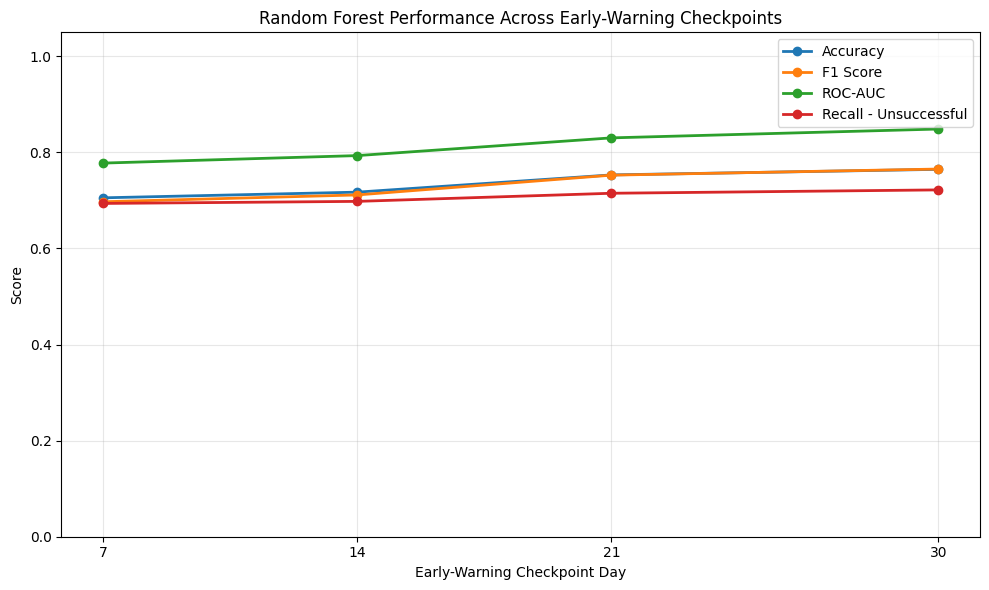

Saved temporal performance plot:
/content/drive/MyDrive/SEAID_Framework/figures/random_forest_temporal_performance.png


In [32]:
plt.figure(figsize=(10, 6))

for metric in [
    "Accuracy",
    "F1 Score",
    "ROC-AUC",
    "Recall - Unsuccessful"
]:
    plt.plot(
        random_forest_temporal_results_df[
            "Checkpoint Day"
        ],
        random_forest_temporal_results_df[
            metric
        ],
        marker="o",
        linewidth=2,
        label=metric
    )

plt.xlabel("Early-Warning Checkpoint Day")
plt.ylabel("Score")

plt.title(
    "Random Forest Performance Across "
    "Early-Warning Checkpoints"
)

plt.xticks([7, 14, 21, 30])
plt.ylim(0, 1.05)
plt.legend()
plt.grid(alpha=0.3)
plt.tight_layout()

RANDOM_FOREST_TEMPORAL_FIGURE_PATH = (
    FIGURE_DIR /
    "random_forest_temporal_performance.png"
)

plt.savefig(
    RANDOM_FOREST_TEMPORAL_FIGURE_PATH,
    dpi=300,
    bbox_inches="tight"
)

plt.show()

print("Saved temporal performance plot:")
print(RANDOM_FOREST_TEMPORAL_FIGURE_PATH)

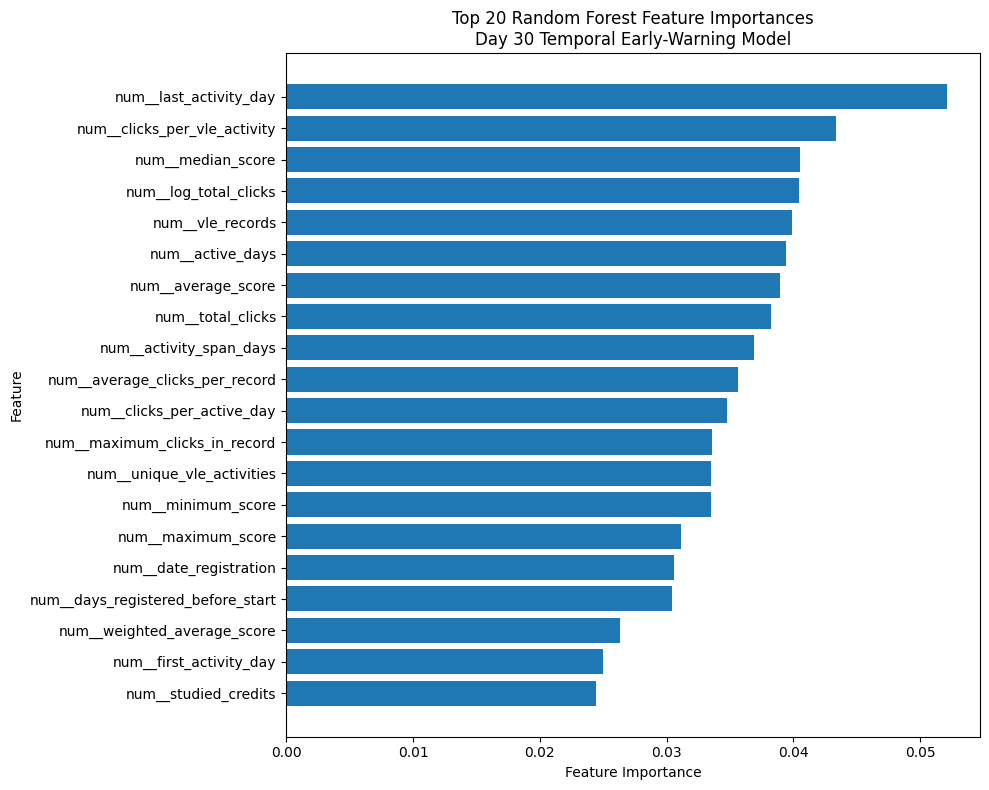

Saved Day 30 feature-importance plot:
/content/drive/MyDrive/SEAID_Framework/figures/random_forest_day30_temporal_feature_importance.png


In [33]:
day30_random_forest_importance = (
    random_forest_temporal_importances[30]
    .head(20)
    .copy()
)

plt.figure(figsize=(10, 8))

plt.barh(
    day30_random_forest_importance[
        "Feature"
    ][::-1],
    day30_random_forest_importance[
        "Importance"
    ][::-1]
)

plt.xlabel("Feature Importance")
plt.ylabel("Feature")

plt.title(
    "Top 20 Random Forest Feature Importances\n"
    "Day 30 Temporal Early-Warning Model"
)

plt.tight_layout()

DAY30_IMPORTANCE_FIGURE_PATH = (
    FIGURE_DIR /
    "random_forest_day30_temporal_feature_importance.png"
)

plt.savefig(
    DAY30_IMPORTANCE_FIGURE_PATH,
    dpi=300,
    bbox_inches="tight"
)

plt.show()

print("Saved Day 30 feature-importance plot:")
print(DAY30_IMPORTANCE_FIGURE_PATH)

In [35]:
random_forest_temporal_results_df

,Model,Checkpoint Day,Students,Original Features,Accuracy,Precision - Successful,Recall - Successful,Recall - Unsuccessful,F1 Score,ROC-AUC,At-Risk Students Missed,Successful Students Flagged
0,Random Forest,7,32593,74,0.7055,0.6772,0.7186,0.6938,0.6973,0.7778,1054,866
1,Random Forest,14,32593,74,0.7173,0.6863,0.7387,0.6981,0.7115,0.7934,1039,804
2,Random Forest,21,32593,74,0.7532,0.7140,0.7959,0.7150,0.7527,0.8303,981,628
3,Random Forest,30,32593,74,0.7648,0.7233,0.8128,0.7220,0.7654,0.8487,957,576


In [40]:
from pathlib import Path

PROJECT_DIR = Path("/content/drive/MyDrive/SEAID_Framework")

for csv_file in PROJECT_DIR.rglob("*.csv"):
    if "random_forest" in csv_file.name.lower():
        print(csv_file)

/content/drive/MyDrive/SEAID_Framework/outputs/random_forest_early_warning_metrics.csv
/content/drive/MyDrive/SEAID_Framework/outputs/random_forest_classification_report.csv
/content/drive/MyDrive/SEAID_Framework/outputs/random_forest_feature_importance.csv
/content/drive/MyDrive/SEAID_Framework/outputs/random_forest_temporal_results.csv
/content/drive/MyDrive/SEAID_Framework/outputs/random_forest_temporal_summary.csv
/content/drive/MyDrive/SEAID_Framework/outputs/random_forest_temporal_feature_importance.csv


In [43]:
from pathlib import Path

PROJECT_DIR = Path(
    "/content/drive/MyDrive/SEAID_Framework"
)

RESULTS_DIR = PROJECT_DIR / "results"
PROCESSED_DATA_DIR = (
    PROJECT_DIR / "data" / "processed"
)
OUTPUTS_DIR = PROJECT_DIR / "outputs"

candidate_files = {
    "Logistic Regression": [
        RESULTS_DIR / "logistic_regression_temporal_results.csv",
        PROCESSED_DATA_DIR / "logistic_regression_temporal_results.csv"
    ],
    "Decision Tree": [
        RESULTS_DIR / "decision_tree_temporal_results.csv",
        PROCESSED_DATA_DIR / "decision_tree_temporal_results.csv"
    ],
    "Random Forest": [
        OUTPUTS_DIR / "random_forest_temporal_results.csv",
        RESULTS_DIR / "random_forest_temporal_results.csv",
        PROCESSED_DATA_DIR / "random_forest_temporal_results.csv"
    ]
}

def find_existing_file(paths):
    for path in paths:
        if path.exists():
            return path
    return None

model_result_files = {}

for model_name, paths in candidate_files.items():
    found_path = find_existing_file(paths)

    if found_path is None:
        print(f"Not found: {model_name}")
    else:
        model_result_files[model_name] = found_path
        print(f"Found {model_name}: {found_path}")

Found Logistic Regression: /content/drive/MyDrive/SEAID_Framework/data/processed/logistic_regression_temporal_results.csv
Found Decision Tree: /content/drive/MyDrive/SEAID_Framework/data/processed/decision_tree_temporal_results.csv
Found Random Forest: /content/drive/MyDrive/SEAID_Framework/outputs/random_forest_temporal_results.csv


In [44]:
all_model_results = []

for model_name, result_path in model_result_files.items():

    model_df = pd.read_csv(result_path)

    if "Model" not in model_df.columns:
        model_df["Model"] = model_name
    else:
        model_df["Model"] = model_name

    all_model_results.append(model_df)

if not all_model_results:
    raise FileNotFoundError(
        "No temporal model result files were found."
    )

all_models_results_df = pd.concat(
    all_model_results,
    ignore_index=True
)

all_models_results_df = (
    all_models_results_df
    .sort_values(
        ["Checkpoint Day", "Model"]
    )
    .reset_index(drop=True)
)

display(all_models_results_df)

,Checkpoint Day,Students,Features,Accuracy,Precision - Successful,Recall - Successful,Recall - Unsuccessful,F1 Score,ROC-AUC,At-Risk Students Missed,Successful Students Flagged,Model,Original Features
0,7,32593,72.0,0.6791,0.6477,0.7020,0.6586,0.6737,0.7424,1175,917,Decision Tree,NaN
1,7,32593,72.0,0.6970,0.6697,0.7065,0.6886,0.6876,0.7698,1072,903,Logistic Regression,NaN
2,7,32593,NaN,0.7055,0.6772,0.7186,0.6938,0.6973,0.7778,1054,866,Random Forest,74.0
3,14,32593,72.0,0.6897,0.6678,0.6815,0.6970,0.6746,0.7589,1043,980,Decision Tree,NaN
4,14,32593,72.0,0.7090,0.6789,0.7277,0.6923,0.7024,0.7844,1059,838,Logistic Regression,NaN
5,14,32593,NaN,0.7173,0.6863,0.7387,0.6981,0.7115,0.7934,1039,804,Random Forest,74.0
6,21,32593,72.0,0.7204,0.6822,0.7631,0.6822,0.7204,0.7898,1094,729,Decision Tree,NaN
7,21,32593,72.0,0.7271,0.6991,0.7407,0.7150,0.7193,0.8056,981,798,Logistic Regression,NaN
8,21,32593,NaN,0.7532,0.7140,0.7959,0.7150,0.7527,0.8303,981,628,Random Forest,74.0
9,30,32593,72.0,0.7446,0.7038,0.7923,0.7019,0.7455,0.8203,1026,639,Decision Tree,NaN


In [45]:
comparison_columns = [
    "Model",
    "Checkpoint Day",
    "Accuracy",
    "Precision - Successful",
    "Recall - Successful",
    "Recall - Unsuccessful",
    "F1 Score",
    "ROC-AUC",
    "At-Risk Students Missed",
    "Successful Students Flagged"
]

available_comparison_columns = [
    column
    for column in comparison_columns
    if column in all_models_results_df.columns
]

model_comparison_df = (
    all_models_results_df[
        available_comparison_columns
    ]
    .copy()
)

display(model_comparison_df)

,Model,Checkpoint Day,Accuracy,Precision - Successful,Recall - Successful,Recall - Unsuccessful,F1 Score,ROC-AUC,At-Risk Students Missed,Successful Students Flagged
0,Decision Tree,7,0.6791,0.6477,0.7020,0.6586,0.6737,0.7424,1175,917
1,Logistic Regression,7,0.6970,0.6697,0.7065,0.6886,0.6876,0.7698,1072,903
2,Random Forest,7,0.7055,0.6772,0.7186,0.6938,0.6973,0.7778,1054,866
3,Decision Tree,14,0.6897,0.6678,0.6815,0.6970,0.6746,0.7589,1043,980
4,Logistic Regression,14,0.7090,0.6789,0.7277,0.6923,0.7024,0.7844,1059,838
5,Random Forest,14,0.7173,0.6863,0.7387,0.6981,0.7115,0.7934,1039,804
6,Decision Tree,21,0.7204,0.6822,0.7631,0.6822,0.7204,0.7898,1094,729
7,Logistic Regression,21,0.7271,0.6991,0.7407,0.7150,0.7193,0.8056,981,798
8,Random Forest,21,0.7532,0.7140,0.7959,0.7150,0.7527,0.8303,981,628
9,Decision Tree,30,0.7446,0.7038,0.7923,0.7019,0.7455,0.8203,1026,639


In [46]:
roc_auc_comparison = (
    all_models_results_df
    .pivot(
        index="Checkpoint Day",
        columns="Model",
        values="ROC-AUC"
    )
    .round(4)
)

display(roc_auc_comparison)

Model,Decision Tree,Logistic Regression,Random Forest
Checkpoint Day,,,
7,0.7424,0.7698,0.7778
14,0.7589,0.7844,0.7934
21,0.7898,0.8056,0.8303
30,0.8203,0.8193,0.8487


In [47]:
accuracy_comparison = (
    all_models_results_df
    .pivot(
        index="Checkpoint Day",
        columns="Model",
        values="Accuracy"
    )
    .round(4)
)

unsuccessful_recall_comparison = (
    all_models_results_df
    .pivot(
        index="Checkpoint Day",
        columns="Model",
        values="Recall - Unsuccessful"
    )
    .round(4)
)

at_risk_missed_comparison = (
    all_models_results_df
    .pivot(
        index="Checkpoint Day",
        columns="Model",
        values="At-Risk Students Missed"
    )
)

print("Accuracy")
display(accuracy_comparison)

print("Recall for Unsuccessful Students")
display(unsuccessful_recall_comparison)

print("At-Risk Students Missed")
display(at_risk_missed_comparison)

Accuracy


Model,Decision Tree,Logistic Regression,Random Forest
Checkpoint Day,,,
7,0.6791,0.6970,0.7055
14,0.6897,0.7090,0.7173
21,0.7204,0.7271,0.7532
30,0.7446,0.7354,0.7648


Recall for Unsuccessful Students


Model,Decision Tree,Logistic Regression,Random Forest
Checkpoint Day,,,
7,0.6586,0.6886,0.6938
14,0.6970,0.6923,0.6981
21,0.6822,0.7150,0.7150
30,0.7019,0.7147,0.7220


At-Risk Students Missed


Model,Decision Tree,Logistic Regression,Random Forest
Checkpoint Day,,,
7,1175,1072,1054
14,1043,1059,1039
21,1094,981,981
30,1026,982,957


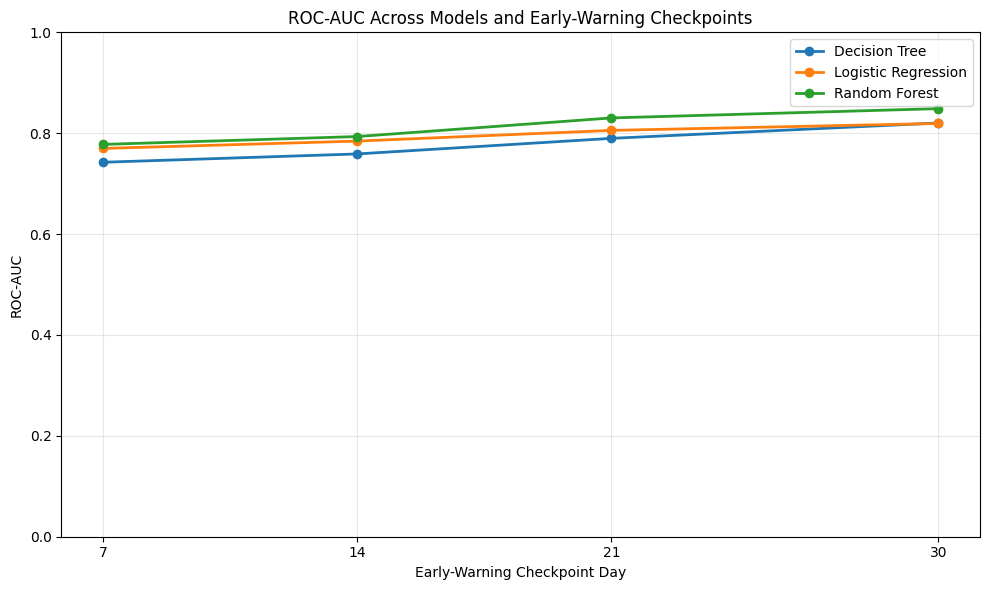

In [48]:
plt.figure(figsize=(10, 6))

for model_name in all_models_results_df["Model"].unique():

    model_data = (
        all_models_results_df[
            all_models_results_df["Model"]
            == model_name
        ]
        .sort_values("Checkpoint Day")
    )

    plt.plot(
        model_data["Checkpoint Day"],
        model_data["ROC-AUC"],
        marker="o",
        linewidth=2,
        label=model_name
    )

plt.xlabel("Early-Warning Checkpoint Day")
plt.ylabel("ROC-AUC")

plt.title(
    "ROC-AUC Across Models and "
    "Early-Warning Checkpoints"
)

plt.xticks([7, 14, 21, 30])
plt.ylim(0, 1.0)
plt.legend()
plt.grid(alpha=0.3)
plt.tight_layout()
plt.show()

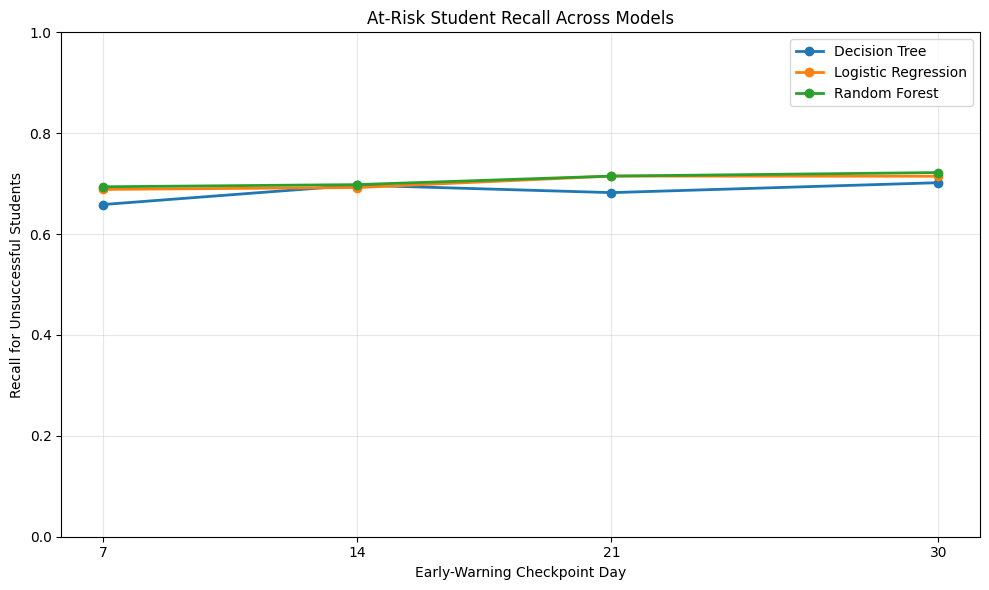

In [49]:
plt.figure(figsize=(10, 6))

for model_name in all_models_results_df["Model"].unique():

    model_data = (
        all_models_results_df[
            all_models_results_df["Model"]
            == model_name
        ]
        .sort_values("Checkpoint Day")
    )

    plt.plot(
        model_data["Checkpoint Day"],
        model_data["Recall - Unsuccessful"],
        marker="o",
        linewidth=2,
        label=model_name
    )

plt.xlabel("Early-Warning Checkpoint Day")
plt.ylabel("Recall for Unsuccessful Students")

plt.title(
    "At-Risk Student Recall Across Models"
)

plt.xticks([7, 14, 21, 30])
plt.ylim(0, 1.0)
plt.legend()
plt.grid(alpha=0.3)
plt.tight_layout()
plt.show()

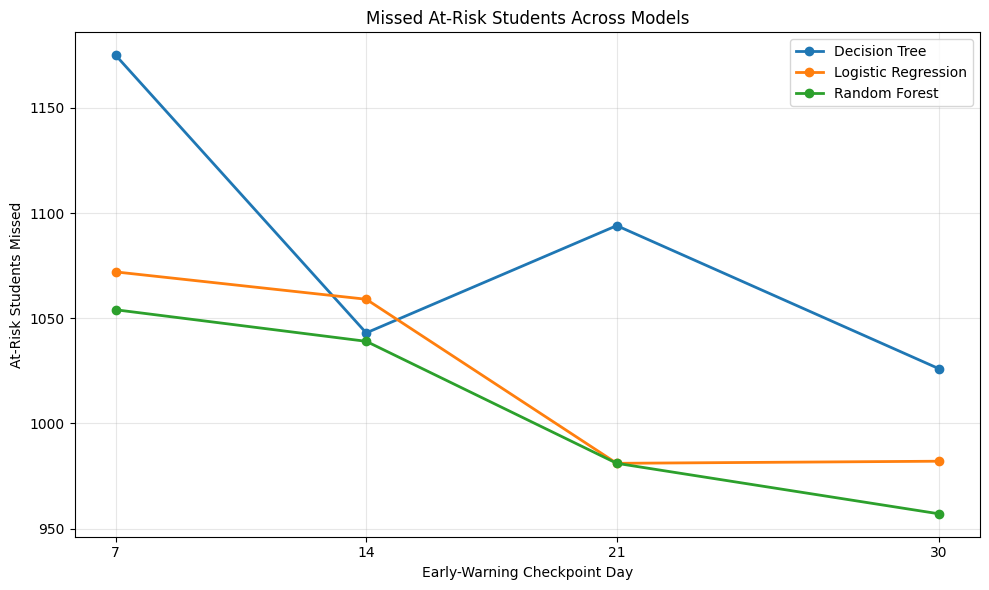

In [50]:
plt.figure(figsize=(10, 6))

for model_name in all_models_results_df["Model"].unique():

    model_data = (
        all_models_results_df[
            all_models_results_df["Model"]
            == model_name
        ]
        .sort_values("Checkpoint Day")
    )

    plt.plot(
        model_data["Checkpoint Day"],
        model_data["At-Risk Students Missed"],
        marker="o",
        linewidth=2,
        label=model_name
    )

plt.xlabel("Early-Warning Checkpoint Day")
plt.ylabel("At-Risk Students Missed")

plt.title(
    "Missed At-Risk Students Across Models"
)

plt.xticks([7, 14, 21, 30])
plt.legend()
plt.grid(alpha=0.3)
plt.tight_layout()
plt.show()

In [51]:
best_by_checkpoint = (
    all_models_results_df
    .sort_values(
        [
            "Checkpoint Day",
            "ROC-AUC"
        ],
        ascending=[
            True,
            False
        ]
    )
    .groupby(
        "Checkpoint Day",
        as_index=False
    )
    .first()
)

display(
    best_by_checkpoint[
        [
            "Checkpoint Day",
            "Model",
            "Accuracy",
            "Recall - Unsuccessful",
            "F1 Score",
            "ROC-AUC",
            "At-Risk Students Missed"
        ]
    ]
)

,Checkpoint Day,Model,Accuracy,Recall - Unsuccessful,F1 Score,ROC-AUC,At-Risk Students Missed
0,7,Random Forest,0.7055,0.6938,0.6973,0.7778,1054
1,14,Random Forest,0.7173,0.6981,0.7115,0.7934,1039
2,21,Random Forest,0.7532,0.7150,0.7527,0.8303,981
3,30,Random Forest,0.7648,0.7220,0.7654,0.8487,957


In [52]:
MODEL_COMPARISON_PATH = (
    RESULTS_DIR /
    "all_models_temporal_comparison.csv"
)

RESULTS_DIR.mkdir(
    parents=True,
    exist_ok=True
)

all_models_results_df.to_csv(
    MODEL_COMPARISON_PATH,
    index=False
)

print("Saved combined comparison:")
print(MODEL_COMPARISON_PATH)

Saved combined comparison:
/content/drive/MyDrive/SEAID_Framework/results/all_models_temporal_comparison.csv


In [53]:
best_by_checkpoint

,Checkpoint Day,Students,Features,Accuracy,Precision - Successful,Recall - Successful,Recall - Unsuccessful,F1 Score,ROC-AUC,At-Risk Students Missed,Successful Students Flagged,Model,Original Features
0,7,32593,72.0,0.7055,0.6772,0.7186,0.6938,0.6973,0.7778,1054,866,Random Forest,74.0
1,14,32593,72.0,0.7173,0.6863,0.7387,0.6981,0.7115,0.7934,1039,804,Random Forest,74.0
2,21,32593,72.0,0.7532,0.7140,0.7959,0.7150,0.7527,0.8303,981,628,Random Forest,74.0
3,30,32593,72.0,0.7648,0.7233,0.8128,0.7220,0.7654,0.8487,957,576,Random Forest,74.0


In [54]:
from pathlib import Path
import pandas as pd

PROJECT_DIR = Path(
    "/content/drive/MyDrive/SEAID_Framework"
)

model_result_files = {
    "Logistic Regression": (
        PROJECT_DIR
        / "data"
        / "processed"
        / "logistic_regression_temporal_results.csv"
    ),
    "Decision Tree": (
        PROJECT_DIR
        / "data"
        / "processed"
        / "decision_tree_temporal_results.csv"
    ),
    "Random Forest": (
        PROJECT_DIR
        / "outputs"
        / "random_forest_temporal_results.csv"
    )
}

all_model_results = []

for model_name, result_path in model_result_files.items():

    if not result_path.exists():
        print(f"Missing: {model_name}")
        print(result_path)
        continue

    model_df = pd.read_csv(result_path)

    # Standardize the model name
    model_df["Model"] = model_name

    # Standardize checkpoint column if needed
    if (
        "Checkpoint Day" not in model_df.columns
        and "Checkpoint" in model_df.columns
    ):
        model_df["Checkpoint Day"] = (
            model_df["Checkpoint"]
            .astype(str)
            .str.extract(r"(\d+)")
            .astype(int)
        )

    all_model_results.append(model_df)

    print(
        f"Loaded {model_name}: "
        f"{len(model_df)} checkpoint rows"
    )

if not all_model_results:
    raise FileNotFoundError(
        "No model result files were loaded."
    )

all_models_results_df = pd.concat(
    all_model_results,
    ignore_index=True,
    sort=False
)

all_models_results_df["Checkpoint Day"] = (
    pd.to_numeric(
        all_models_results_df["Checkpoint Day"],
        errors="coerce"
    )
)

all_models_results_df = (
    all_models_results_df
    .dropna(subset=["Checkpoint Day"])
    .sort_values(
        ["Checkpoint Day", "Model"]
    )
    .reset_index(drop=True)
)

display(
    all_models_results_df[
        [
            "Model",
            "Checkpoint Day",
            "Accuracy",
            "Recall - Unsuccessful",
            "F1 Score",
            "ROC-AUC",
            "At-Risk Students Missed",
            "Successful Students Flagged"
        ]
    ]
)

Loaded Logistic Regression: 4 checkpoint rows
Loaded Decision Tree: 4 checkpoint rows
Loaded Random Forest: 4 checkpoint rows


,Model,Checkpoint Day,Accuracy,Recall - Unsuccessful,F1 Score,ROC-AUC,At-Risk Students Missed,Successful Students Flagged
0,Decision Tree,7,0.6791,0.6586,0.6737,0.7424,1175,917
1,Logistic Regression,7,0.6970,0.6886,0.6876,0.7698,1072,903
2,Random Forest,7,0.7055,0.6938,0.6973,0.7778,1054,866
3,Decision Tree,14,0.6897,0.6970,0.6746,0.7589,1043,980
4,Logistic Regression,14,0.7090,0.6923,0.7024,0.7844,1059,838
5,Random Forest,14,0.7173,0.6981,0.7115,0.7934,1039,804
6,Decision Tree,21,0.7204,0.6822,0.7204,0.7898,1094,729
7,Logistic Regression,21,0.7271,0.7150,0.7193,0.8056,981,798
8,Random Forest,21,0.7532,0.7150,0.7527,0.8303,981,628
9,Decision Tree,30,0.7446,0.7019,0.7455,0.8203,1026,639


In [55]:
best_by_checkpoint = (
    all_models_results_df
    .sort_values(
        [
            "Checkpoint Day",
            "ROC-AUC"
        ],
        ascending=[
            True,
            False
        ]
    )
    .groupby(
        "Checkpoint Day",
        as_index=False
    )
    .first()
)

display(
    best_by_checkpoint[
        [
            "Checkpoint Day",
            "Model",
            "Accuracy",
            "Recall - Unsuccessful",
            "F1 Score",
            "ROC-AUC",
            "At-Risk Students Missed",
            "Successful Students Flagged"
        ]
    ]
)

,Checkpoint Day,Model,Accuracy,Recall - Unsuccessful,F1 Score,ROC-AUC,At-Risk Students Missed,Successful Students Flagged
0,7,Random Forest,0.7055,0.6938,0.6973,0.7778,1054,866
1,14,Random Forest,0.7173,0.6981,0.7115,0.7934,1039,804
2,21,Random Forest,0.7532,0.7150,0.7527,0.8303,981,628
3,30,Random Forest,0.7648,0.7220,0.7654,0.8487,957,576


## Best Model by Early-Warning Checkpoint

Random Forest achieved the highest ROC-AUC among the evaluated models at every early-warning checkpoint. Its performance improved steadily as additional student information became available, increasing from an ROC-AUC of 0.7778 at Day 7 to 0.8487 at Day 30.

The Day 30 Random Forest model produced the strongest overall performance, with an accuracy of 0.7648, an F1 score of 0.7654, and unsuccessful-student recall of 0.7220. However, the Day 21 model already achieved an ROC-AUC of 0.8303, suggesting that Day 21 may offer a useful balance between early intervention and predictive performance.

These findings establish Random Forest as the strongest benchmark model so far. The next stage of the analysis will evaluate whether XGBoost can improve upon this performance.

## Interpretation of Temporal Random Forest Results

Random Forest performance improved consistently as additional student information became available. Accuracy increased from 0.7055 at Day 7 to 0.7648 at Day 30, while ROC-AUC increased from 0.7778 to 0.8487.

The model also became more effective at identifying students who ultimately did not succeed. Recall for unsuccessful students increased from 0.6938 at Day 7 to 0.7220 at Day 30. Correspondingly, the number of at-risk students incorrectly predicted as successful declined from 1,054 at Day 7 to 957 at Day 30.

Day 30 produced the strongest overall performance. However, the Day 21 model already achieved an ROC-AUC of 0.8303 and an accuracy of 0.7532, suggesting that Day 21 may represent a useful balance between predictive performance and the ability to intervene early.

Although performance improved over time, the model continued to miss a substantial number of at-risk students. Future threshold analysis should evaluate whether lowering the classification threshold improves recall for unsuccessful students while maintaining an acceptable number of false alerts.